# Árboles de decisión

In [339]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from utils2 import get_classifier_metrics
import pickle
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score


##  1. Árbol de Clasificación

### Paso 1. Lectura del conjunto de datos procesado

In [340]:
file_path = '/workspaces/CarlosRestrepo-machine-learning-python/data/processed/diabetes.pkl'

# Abrir el archivo en modo binario de lectura ('rb')
with open(file_path, 'rb') as file:
    # Cargar el objeto (tu DataFrame) usando el manejador de archivo 'file'
    df = pickle.load(file)

### Paso 2. Selección de variables

In [341]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,0,26.6,0.351,31,0
2,8.0,183.0,64.0,29.0,0,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94,28.1,0.167,21,0
4,4.0,137.0,40.0,35.0,168,43.1,2.288,33,1


### Paso 3. Split

In [342]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)
X_train.shape

(614, 8)

In [343]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [344]:
y.unique()

array([1, 0])

Siendo:
- La clase `0` negativo en diabetis
- La clase `1` positivo en diabetis

### Paso 4. Análisis y Visualización

<Axes: >

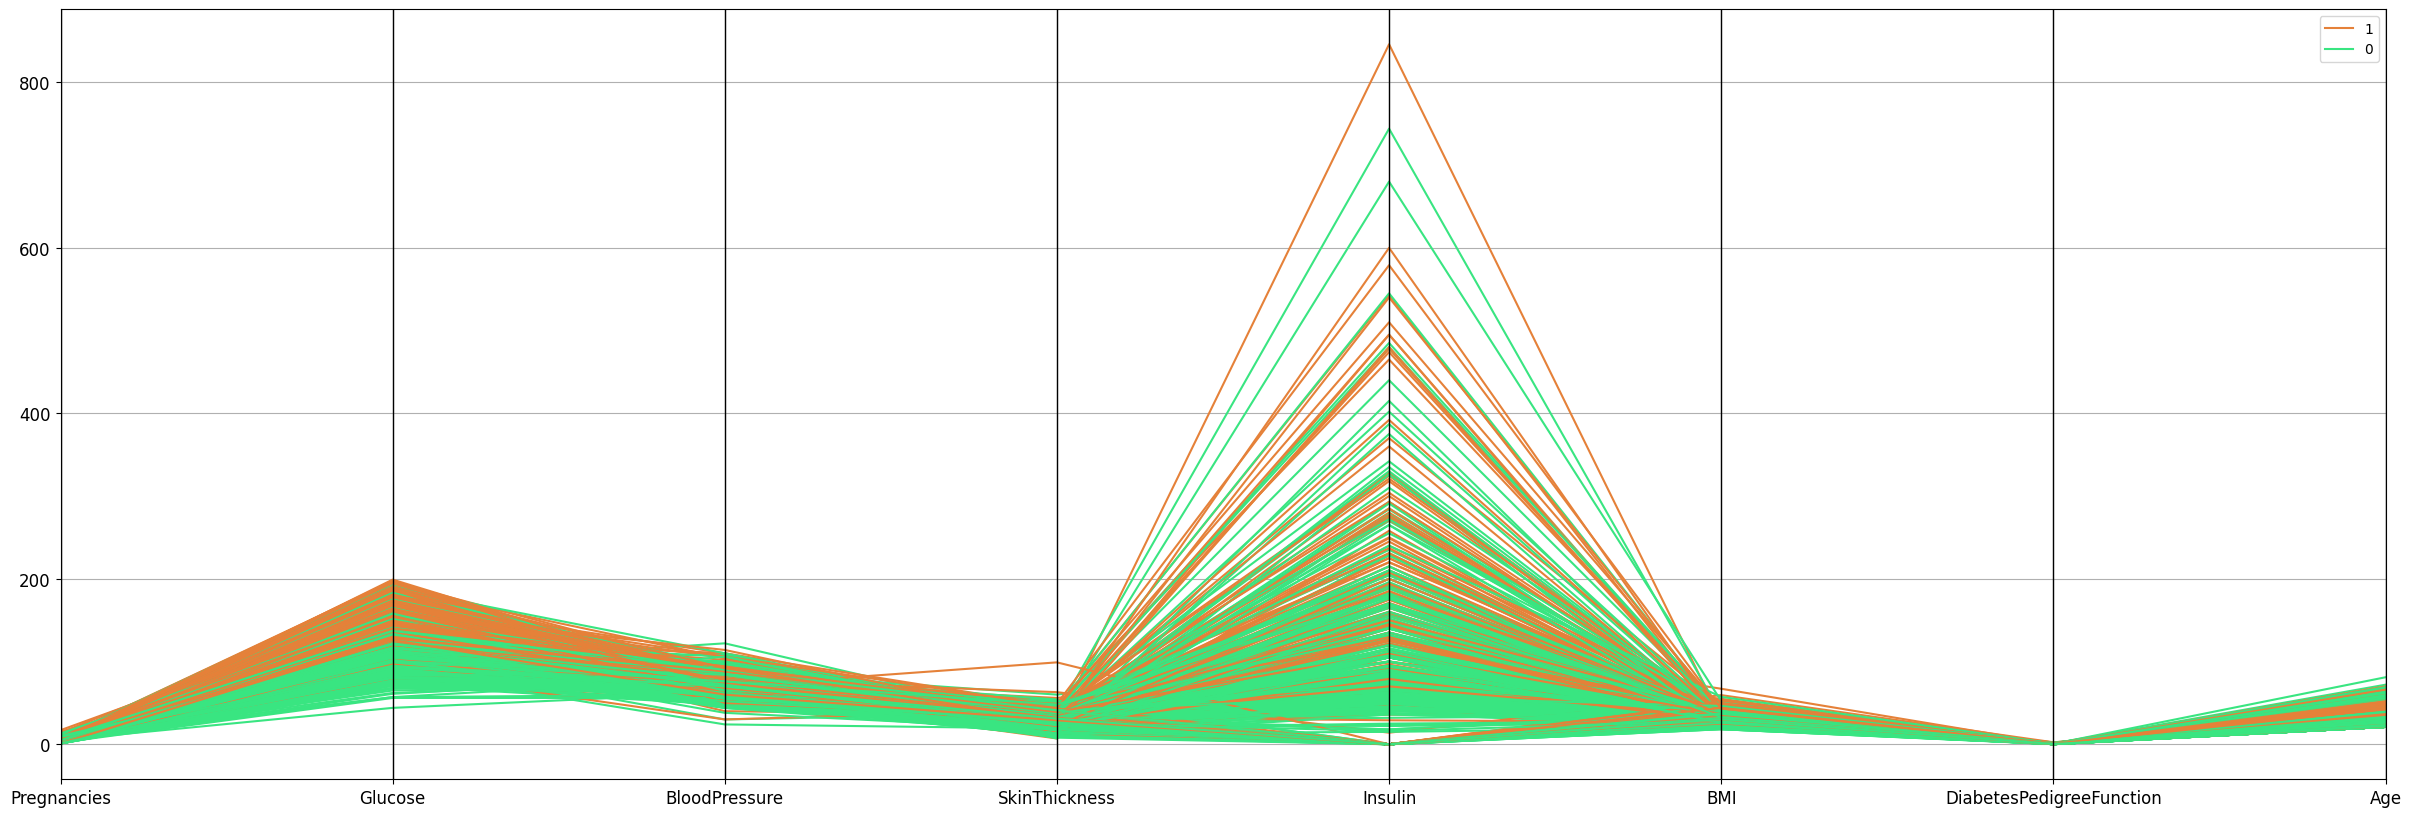

In [345]:
df = X
df['Name'] = y
plt.figure(figsize=(30, 10))
plt.rcParams['xtick.labelsize'] = 12 
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelsize'] = 14 

pd.plotting.parallel_coordinates(df,
                                 'Name',
                                 color=('#E58139', '#39E581'))

### Paso 5. Modelado y Ajuste

In [346]:
model = DecisionTreeClassifier(criterion="gini", random_state=18)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,18
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Ahora visualizamos el árbol de decisiones.
Esta visualización representa todos los pasos que ha seguido el modelo hasta la construcción del árbol.

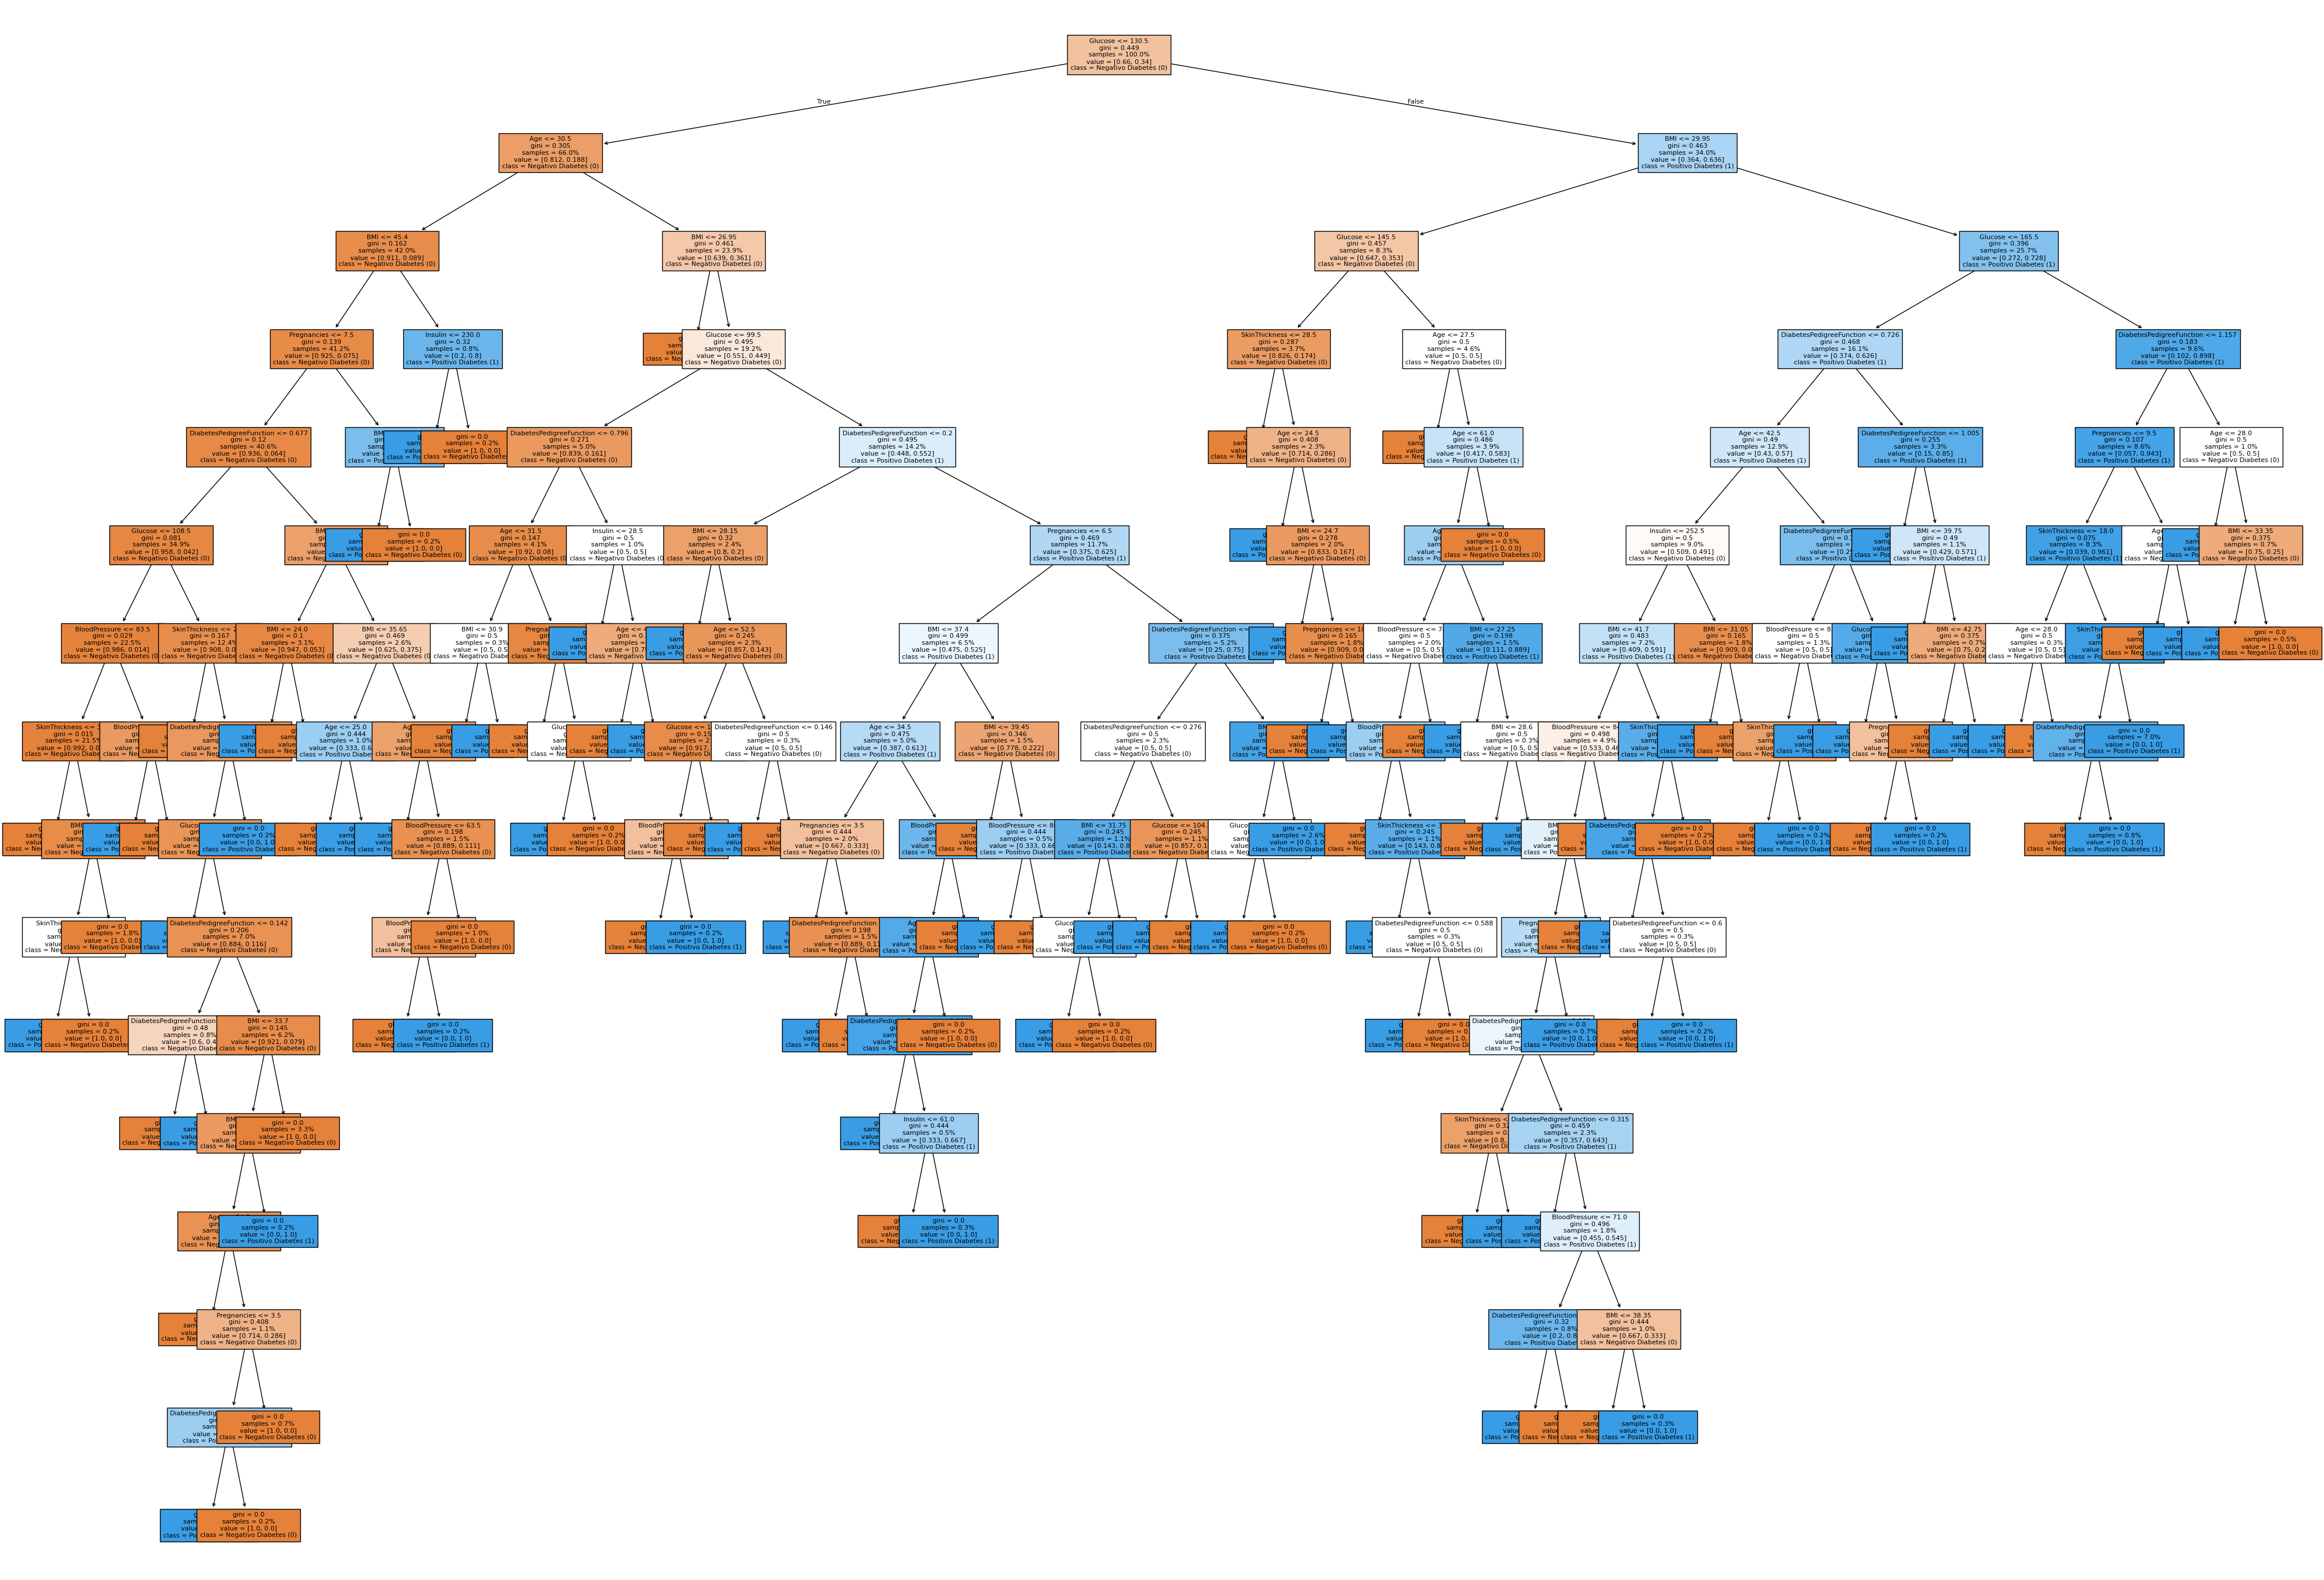

In [347]:
nombres_de_clase = ['Negativo Diabetes (0)', 'Positivo Diabetes (1)']

plt.figure(figsize=(50, 35))

tree.plot_tree(model,
               feature_names=list(X_train.columns),
               class_names=nombres_de_clase,
               filled=True,
               fontsize=8,
               proportion=True)
plt.show()

### Paso 6. Predicción

In [348]:
y_pred_test = model.predict(X_test)
y_pred_test

array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [349]:
y_pred_train = model.predict(X_train)
y_pred_train

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,

In [350]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.681818,0.681818,0.681818,0.681818


#### Obervaciones:
> - El modelo tiene una precisión del 0.68%.

In [351]:
criterios = ['gini', 'entropy', 'log_loss']
resultados = {}


for criterio in criterios:

    model = DecisionTreeClassifier(criterion=criterio, 
                                   random_state=18)
    
    model.fit(X_train, y_train)
    
    y_pred_test = model.predict(X_test)
    precision_test = accuracy_score(y_test, y_pred_test)
    
    resultados[criterio] = precision_test

resultados

{'gini': 0.6818181818181818,
 'entropy': 0.7012987012987013,
 'log_loss': 0.7012987012987013}

#### Visualización

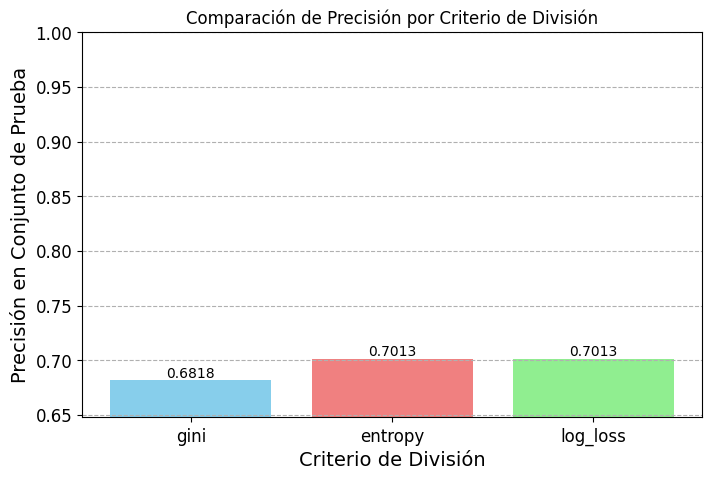

In [352]:
df_resultados = pd.DataFrame(resultados.items(), columns=['Criterio', 'Precisión (Test)'])

plt.figure(figsize=(8, 5))
plt.bar(df_resultados['Criterio'], 
        df_resultados['Precisión (Test)'], 
        color=['skyblue', 'lightcoral', 'lightgreen'])

plt.title('Comparación de Precisión por Criterio de División')
plt.xlabel('Criterio de División')
plt.ylabel('Precisión en Conjunto de Prueba')
plt.ylim(min(df_resultados['Precisión (Test)']) * 0.95, 1.0)
plt.grid(axis='y', linestyle='--')

# 9. Mostrar el valor de precisión encima de cada barra
for i, valor in enumerate(df_resultados['Precisión (Test)']):
    plt.text(i, valor, f'{valor:.4f}', ha='center', va='bottom')

#### Observaciones:
> - El criterio de Gini alcanza la mayor precisión entre los tres criterios de división probados, aún así la entropía y el logaritmo de la pérdida presentan el mismo rendimiento y una precision menor que el criterio gini.

### Entrenar modelo con Hiperparametros.

In [353]:
params= {
    'max_depth': [3, 5, 7, 10, 15, 20], 
    'min_samples_split': [2, 4, 8, 16, 32, 64, 128],
    'min_samples_leaf': [1, 5, 10, 20, 40, 60],
    'criterion': ['gini', 'entropy'] 
}

dt_model_params = DecisionTreeClassifier(random_state=18)

random_search = RandomizedSearchCV(dt_model_params, params, 
    scoring='accuracy', cv=5
)

random_search.fit(X_train, y_train)


random_search.best_params_

{'min_samples_split': 128,
 'min_samples_leaf': 5,
 'max_depth': 7,
 'criterion': 'gini'}

In [354]:
random_search.best_score_

np.float64(0.7687591630014661)

In [355]:
y_pred_test2 = random_search.predict(X_test)
y_pred_test2

array([0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0])

In [356]:
y_pred_train2 = random_search.predict(X_train)
y_pred_train2

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,

In [357]:
get_classifier_metrics(y_pred_test2, y_test, y_pred_train2, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,0.783388,0.783388,0.783388,0.783388
Test set,0.727273,0.727273,0.727273,0.727273


#### Observaciones:
> - Tras el ajuste de hiperparámetros, el árbol de decisión alcanzó una precisión de prueba del 72%. 
> - La optimización de hiperparámetros el modelo mejoró 0.4% puntos conceptuales la generalización del modelo.

## Guardar Modelo

In [358]:
with open('../models/decision-tree-diabetes.pkl', 'wb') as file:
    pickle.dump(model, file)